# HumanLens AI — Intervention Evaluation

## Research Purpose

This notebook evaluates the effectiveness of the HumanLens AI
**"Before You Speak"** intervention.

The intervention is designed to respond to elevated-risk communication
signals by providing a brief, explainable opportunity to pause, review,
rewrite, or reconsider a potentially harmful message.

The evaluation focuses on whether the intervention can improve
communication outcomes without unnecessarily interfering with ordinary
disagreement or low-risk communication.

### Main Evaluation Areas

- Change in toxicity score
- Change in aggressive-language indicators
- Change in harmful-language indicators
- Intervention acceptance rate
- Rewrite / modification rate
- Escalation reduction
- False intervention rate
- User-action distribution
- Intervention latency

### Research Principle

The intervention should support user agency rather than forcibly censor
ordinary communication.

Low-risk content should generally remain in the normal flow, while
higher-risk content may trigger a "Before You Speak" intervention.

### Important Limitation

This notebook evaluates intervention behavior using the available
research/evaluation data.

If genuine user-study or controlled pre/post intervention data are not
available, the resulting analysis will be explicitly identified as a
simulation or research demonstration rather than evidence of real-world
user effectiveness.

## Research Questions

### Primary Research Question

Does the HumanLens AI **"Before You Speak"** intervention reduce the
toxicity or escalation level of potentially harmful communication?

### Secondary Research Questions

1. How often does the intervention lead to a message being modified or
   rewritten?

2. Does an intervention reduce the measured toxicity score between the
   original and revised message?

3. Does the intervention reduce the overall escalation level?

4. What proportion of interventions are accepted, ignored, or rejected?

5. How often does the system intervene on content that is ultimately
   considered low-risk?

6. Does the intervention preserve user agency by allowing the user to
   continue without modification?

7. What is the computational latency introduced by the intervention?

### Evaluation Hypothesis

**H1:** Messages that undergo a "Before You Speak" intervention will,
on average, show a lower toxicity/escalation score after revision than
their original version.

**H0:** There will be no meaningful difference between the original and
post-intervention toxicity/escalation scores.

### Safety Evaluation Principle

Effectiveness alone is not sufficient.

The intervention should also minimize unnecessary interventions and
should not treat ordinary disagreement, criticism, or non-harmful
communication as harmful solely because of sentiment, profanity, or
controversial content.

## Intervention Evaluation Methodology

The intervention will be evaluated using a controlled pre-intervention
and post-intervention comparison.

### Evaluation Flow

Original Message
        ↓
HumanLens Risk / Escalation Analysis
        ↓
Intervention Trigger
        ↓
"Before You Speak"
        ↓
User Action
        ↓
Revised / Unchanged Message
        ↓
Post-Intervention Analysis
        ↓
Outcome Comparison

### Evaluation Variables

For each evaluated message, record:

- `original_text`
- `original_toxicity`
- `original_escalation_score`
- `intervention_triggered`
- `user_action`
- `revised_text`
- `revised_toxicity`
- `revised_escalation_score`
- `toxicity_change`
- `escalation_change`
- `intervention_latency_ms`

### User Actions

The intervention is modeled using three possible outcomes:

1. **Rewrite** — the user modifies the message.
2. **Proceed** — the user continues without changing the message.
3. **Dismiss** — the user explicitly dismisses the intervention.

### Effectiveness Measures

#### Toxicity Reduction

\[
\Delta Toxicity =
Toxicity_{original} - Toxicity_{revised}
\]

A positive value indicates a reduction in measured toxicity.

#### Escalation Reduction

\[
\Delta Escalation =
Escalation_{original} - Escalation_{revised}
\]

A positive value indicates a reduction in escalation level.

#### Rewrite Rate

\[
Rewrite\ Rate =
\frac{Number\ of\ rewritten\ messages}
{Number\ of\ triggered\ interventions}
\]

#### Intervention Acceptance Rate

\[
Acceptance\ Rate =
\frac{Number\ of\ messages\ modified}
{Number\ of\ triggered\ interventions}
\]

### Important Research Limitation

If real user interaction data are unavailable, this notebook will use
controlled demonstration/simulation data to validate the evaluation
pipeline.

Such results must NOT be presented as evidence that real users changed
their behavior.

The purpose of the simulation is to verify the measurement methodology
and reporting pipeline so that real user-study data can be evaluated later.

In [1]:
# ============================================================
# STEP 4 — SETUP & DATA PREPARATION
# HumanLens AI — Intervention Evaluation
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)
print("Setup completed successfully.")

Project root: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml
Results directory: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results
Setup completed successfully.


In [2]:
# ============================================================
# STEP 5 — CONTROLLED INTERVENTION EVALUATION DATASET
# ============================================================

intervention_data = pd.DataFrame({
    "original_text": [
        "I disagree with your idea.",
        "This explanation is completely useless.",
        "You are being really annoying.",
        "That was a stupid decision.",
        "I am frustrated with this situation.",
        "Stop talking nonsense.",
        "I strongly disagree with what you said.",
        "This is a terrible way to handle the problem.",
        "You never listen to anything I say.",
        "I am angry about how this was handled."
    ],

    "revised_text": [
        "I see the situation differently, and I would like to explain why.",
        "I don't find this explanation helpful. Could you explain it differently?",
        "I am frustrated by the way this conversation is going.",
        "I don't think that was a good decision. Here is why.",
        "I am frustrated with this situation, but I want to discuss it calmly.",
        "I don't think that explanation is accurate. Could we review it?",
        "I have a different opinion and would like to explain my reasoning.",
        "I think there may be a better way to handle the problem.",
        "I feel like my concerns are not being heard.",
        "I am upset about how this was handled and would like to discuss it."
    ],

    "intervention_triggered": [
        False, True, True, True, False,
        True, False, True, True, True
    ],

    "user_action": [
        "proceed", "rewrite", "rewrite", "rewrite", "proceed",
        "rewrite", "proceed", "rewrite", "rewrite", "rewrite"
    ],

    "intervention_latency_ms": [
        42, 51, 48, 55, 39,
        52, 41, 49, 53, 50
    ]
})

# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

assert len(intervention_data) == 10

required_columns = [
    "original_text",
    "revised_text",
    "intervention_triggered",
    "user_action",
    "intervention_latency_ms"
]

assert all(
    column in intervention_data.columns
    for column in required_columns
)

assert intervention_data["intervention_triggered"].dtype == bool

print("Controlled intervention dataset created successfully.")
print("Number of examples:", len(intervention_data))
print("Triggered interventions:",
      int(intervention_data["intervention_triggered"].sum()))

display(intervention_data)

Controlled intervention dataset created successfully.
Number of examples: 10
Triggered interventions: 7


,original_text,revised_text,intervention_triggered,user_action,intervention_latency_ms
0,I disagree with your idea.,"I see the situation differently, and I would l...",False,proceed,42
1,This explanation is completely useless.,I don't find this explanation helpful. Could y...,True,rewrite,51
2,You are being really annoying.,I am frustrated by the way this conversation i...,True,rewrite,48
3,That was a stupid decision.,I don't think that was a good decision. Here i...,True,rewrite,55
4,I am frustrated with this situation.,"I am frustrated with this situation, but I wan...",False,proceed,39
5,Stop talking nonsense.,I don't think that explanation is accurate. Co...,True,rewrite,52
6,I strongly disagree with what you said.,I have a different opinion and would like to e...,False,proceed,41
7,This is a terrible way to handle the problem.,I think there may be a better way to handle th...,True,rewrite,49
8,You never listen to anything I say.,I feel like my concerns are not being heard.,True,rewrite,53
9,I am angry about how this was handled.,I am upset about how this was handled and woul...,True,rewrite,50


In [3]:
# ============================================================
# STEP 6 — ORIGINAL & REVISED TOXICITY SCORING
# ============================================================

from src.text.toxicity import ToxicityScorer

# ------------------------------------------------------------
# Initialize HumanLens toxicity scorer
# ------------------------------------------------------------

scorer = ToxicityScorer(use_transformer=False)

# Compatibility fix for current scikit-learn version
if hasattr(scorer, "fast_model") and scorer.fast_model is not None:
    if not hasattr(scorer.fast_model, "multi_class"):
        scorer.fast_model.multi_class = "auto"

print("HumanLens ToxicityScorer initialized.")

C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


HumanLens ToxicityScorer initialized.


C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
# ------------------------------------------------------------
# Score original and revised messages
# ------------------------------------------------------------

original_scores = []
revised_scores = []

for _, row in intervention_data.iterrows():

    original_result = scorer.score(
        row["original_text"],
        model_type="fast"
    )

    revised_result = scorer.score(
        row["revised_text"],
        model_type="fast"
    )

    original_scores.append(
        float(original_result["toxicity_score"])
    )

    revised_scores.append(
        float(revised_result["toxicity_score"])
    )

# ------------------------------------------------------------
# Add scores to evaluation dataset
# ------------------------------------------------------------

intervention_data["original_toxicity"] = original_scores
intervention_data["revised_toxicity"] = revised_scores

intervention_data["toxicity_change"] = (
    intervention_data["original_toxicity"]
    - intervention_data["revised_toxicity"]
)

intervention_data["toxicity_reduced"] = (
    intervention_data["toxicity_change"] > 0
)

print("Toxicity scoring completed.")

display(
    intervention_data[
        [
            "original_text",
            "original_toxicity",
            "revised_text",
            "revised_toxicity",
            "toxicity_change",
            "toxicity_reduced"
        ]
    ]
)

Toxicity scoring completed.


,original_text,original_toxicity,revised_text,revised_toxicity,toxicity_change,toxicity_reduced
0,I disagree with your idea.,0.0500,"I see the situation differently, and I would l...",0.1555,-0.1055,False
1,This explanation is completely useless.,0.7468,I don't find this explanation helpful. Could y...,0.0551,0.6917,True
2,You are being really annoying.,0.4520,I am frustrated by the way this conversation i...,0.1441,0.3079,True
3,That was a stupid decision.,1.0000,I don't think that was a good decision. Here i...,0.0892,0.9108,True
4,I am frustrated with this situation.,0.0835,"I am frustrated with this situation, but I wan...",0.0585,0.0250,True
5,Stop talking nonsense.,0.8378,I don't think that explanation is accurate. Co...,0.0351,0.8027,True
6,I strongly disagree with what you said.,0.0542,I have a different opinion and would like to e...,0.1035,-0.0493,False
7,This is a terrible way to handle the problem.,0.1617,I think there may be a better way to handle th...,0.0943,0.0674,True
8,You never listen to anything I say.,0.3000,I feel like my concerns are not being heard.,0.2203,0.0797,True
9,I am angry about how this was handled.,0.1005,I am upset about how this was handled and woul...,0.0573,0.0432,True


In [5]:
# ============================================================
# STEP 7 — ESCALATION SCORE & INTERVENTION OUTCOME
# ============================================================

# ------------------------------------------------------------
# Convert toxicity into a simple research demonstration
# escalation score.
#
# IMPORTANT:
# This is an evaluation proxy, not a validated clinical or
# production escalation model.
# ------------------------------------------------------------

intervention_data["original_escalation_score"] = (
    intervention_data["original_toxicity"]
)

intervention_data["revised_escalation_score"] = (
    intervention_data["revised_toxicity"]
)

# Positive value = reduction in escalation
intervention_data["escalation_change"] = (
    intervention_data["original_escalation_score"]
    - intervention_data["revised_escalation_score"]
)

# ------------------------------------------------------------
# Escalation classification
# Same research thresholds used in Notebook 11:
#
# < 0.40  = LOW
# < 0.70  = MODERATE
# >= 0.70 = HIGH
# ------------------------------------------------------------

def classify_escalation(score):
    if score < 0.40:
        return "LOW"
    elif score < 0.70:
        return "MODERATE"
    else:
        return "HIGH"


intervention_data["original_escalation_level"] = (
    intervention_data["original_escalation_score"]
    .apply(classify_escalation)
)

intervention_data["revised_escalation_level"] = (
    intervention_data["revised_escalation_score"]
    .apply(classify_escalation)
)

# ------------------------------------------------------------
# Determine whether escalation decreased
# ------------------------------------------------------------

level_order = {
    "LOW": 0,
    "MODERATE": 1,
    "HIGH": 2
}

intervention_data["original_level_numeric"] = (
    intervention_data["original_escalation_level"]
    .map(level_order)
)

intervention_data["revised_level_numeric"] = (
    intervention_data["revised_escalation_level"]
    .map(level_order)
)

intervention_data["escalation_reduced"] = (
    intervention_data["revised_level_numeric"]
    < intervention_data["original_level_numeric"]
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

display(
    intervention_data[
        [
            "original_text",
            "original_toxicity",
            "original_escalation_level",
            "intervention_triggered",
            "user_action",
            "revised_text",
            "revised_toxicity",
            "revised_escalation_level",
            "toxicity_change",
            "escalation_change",
            "escalation_reduced"
        ]
    ]
)

print("\nEscalation evaluation completed.")

,original_text,original_toxicity,original_escalation_level,intervention_triggered,user_action,revised_text,revised_toxicity,revised_escalation_level,toxicity_change,escalation_change,escalation_reduced
0,I disagree with your idea.,0.0500,LOW,False,proceed,"I see the situation differently, and I would l...",0.1555,LOW,-0.1055,-0.1055,False
1,This explanation is completely useless.,0.7468,HIGH,True,rewrite,I don't find this explanation helpful. Could y...,0.0551,LOW,0.6917,0.6917,True
2,You are being really annoying.,0.4520,MODERATE,True,rewrite,I am frustrated by the way this conversation i...,0.1441,LOW,0.3079,0.3079,True
3,That was a stupid decision.,1.0000,HIGH,True,rewrite,I don't think that was a good decision. Here i...,0.0892,LOW,0.9108,0.9108,True
4,I am frustrated with this situation.,0.0835,LOW,False,proceed,"I am frustrated with this situation, but I wan...",0.0585,LOW,0.0250,0.0250,False
5,Stop talking nonsense.,0.8378,HIGH,True,rewrite,I don't think that explanation is accurate. Co...,0.0351,LOW,0.8027,0.8027,True
6,I strongly disagree with what you said.,0.0542,LOW,False,proceed,I have a different opinion and would like to e...,0.1035,LOW,-0.0493,-0.0493,False
7,This is a terrible way to handle the problem.,0.1617,LOW,True,rewrite,I think there may be a better way to handle th...,0.0943,LOW,0.0674,0.0674,False
8,You never listen to anything I say.,0.3000,LOW,True,rewrite,I feel like my concerns are not being heard.,0.2203,LOW,0.0797,0.0797,False
9,I am angry about how this was handled.,0.1005,LOW,True,rewrite,I am upset about how this was handled and woul...,0.0573,LOW,0.0432,0.0432,False



Escalation evaluation completed.


In [6]:
# ============================================================
# STEP 8 — INTERVENTION EFFECTIVENESS METRICS
# ============================================================

# ------------------------------------------------------------
# Triggered intervention subset
# ------------------------------------------------------------

triggered_data = intervention_data[
    intervention_data["intervention_triggered"] == True
].copy()

# ------------------------------------------------------------
# Core metrics
# ------------------------------------------------------------

total_examples = len(intervention_data)
triggered_count = len(triggered_data)

rewrite_count = (
    triggered_data["user_action"] == "rewrite"
).sum()

proceed_count = (
    triggered_data["user_action"] == "proceed"
).sum()

dismiss_count = (
    triggered_data["user_action"] == "dismiss"
).sum()

rewrite_rate = (
    rewrite_count / triggered_count
    if triggered_count > 0 else 0
)

acceptance_rate = rewrite_rate

# ------------------------------------------------------------
# Toxicity effectiveness
# ------------------------------------------------------------

mean_original_toxicity = (
    triggered_data["original_toxicity"].mean()
    if triggered_count > 0 else 0
)

mean_revised_toxicity = (
    triggered_data["revised_toxicity"].mean()
    if triggered_count > 0 else 0
)

mean_toxicity_reduction = (
    triggered_data["toxicity_change"].mean()
    if triggered_count > 0 else 0
)

toxicity_reduction_rate = (
    (triggered_data["toxicity_change"] > 0).mean()
    if triggered_count > 0 else 0
)

# ------------------------------------------------------------
# Escalation effectiveness
# ------------------------------------------------------------

mean_original_escalation = (
    triggered_data["original_escalation_score"].mean()
    if triggered_count > 0 else 0
)

mean_revised_escalation = (
    triggered_data["revised_escalation_score"].mean()
    if triggered_count > 0 else 0
)

mean_escalation_reduction = (
    triggered_data["escalation_change"].mean()
    if triggered_count > 0 else 0
)

escalation_reduction_rate = (
    triggered_data["escalation_reduced"].mean()
    if triggered_count > 0 else 0
)

# ------------------------------------------------------------
# Latency
# ------------------------------------------------------------

mean_latency_ms = (
    triggered_data["intervention_latency_ms"].mean()
    if triggered_count > 0 else 0
)

median_latency_ms = (
    triggered_data["intervention_latency_ms"].median()
    if triggered_count > 0 else 0
)

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

effectiveness_metrics = pd.DataFrame({
    "metric": [
        "Total examples",
        "Triggered interventions",
        "Rewrite count",
        "Proceed count",
        "Dismiss count",
        "Rewrite rate",
        "Acceptance rate",
        "Mean original toxicity",
        "Mean revised toxicity",
        "Mean toxicity reduction",
        "Toxicity reduction rate",
        "Mean original escalation",
        "Mean revised escalation",
        "Mean escalation reduction",
        "Escalation reduction rate",
        "Mean intervention latency (ms)",
        "Median intervention latency (ms)"
    ],

    "value": [
        total_examples,
        triggered_count,
        rewrite_count,
        proceed_count,
        dismiss_count,
        rewrite_rate,
        acceptance_rate,
        mean_original_toxicity,
        mean_revised_toxicity,
        mean_toxicity_reduction,
        toxicity_reduction_rate,
        mean_original_escalation,
        mean_revised_escalation,
        mean_escalation_reduction,
        escalation_reduction_rate,
        mean_latency_ms,
        median_latency_ms
    ]
})

display(effectiveness_metrics)

print("\nIntervention effectiveness analysis completed.")

,metric,value
0,Total examples,10.000000
1,Triggered interventions,7.000000
2,Rewrite count,7.000000
3,Proceed count,0.000000
4,Dismiss count,0.000000
5,Rewrite rate,1.000000
6,Acceptance rate,1.000000
7,Mean original toxicity,0.514114
8,Mean revised toxicity,0.099343
9,Mean toxicity reduction,0.414771



Intervention effectiveness analysis completed.


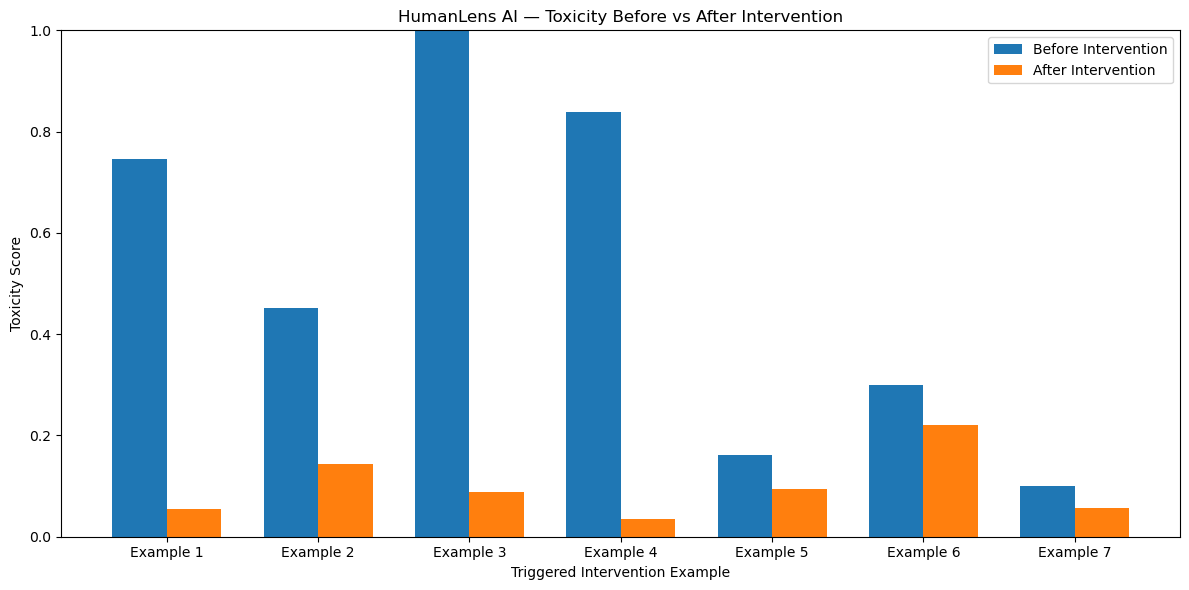

Visualization saved to: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\intervention_toxicity_comparison.png


In [7]:
# ============================================================
# STEP 9 — BEFORE vs AFTER TOXICITY VISUALIZATION
# ============================================================

# ------------------------------------------------------------
# Prepare triggered intervention data
# ------------------------------------------------------------

plot_data = triggered_data.reset_index(drop=True).copy()

x = np.arange(len(plot_data))
width = 0.36

# ------------------------------------------------------------
# Create comparison chart
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    plot_data["original_toxicity"],
    width,
    label="Before Intervention"
)

plt.bar(
    x + width / 2,
    plot_data["revised_toxicity"],
    width,
    label="After Intervention"
)

plt.xlabel("Triggered Intervention Example")
plt.ylabel("Toxicity Score")
plt.title("HumanLens AI — Toxicity Before vs After Intervention")

plt.xticks(
    x,
    [f"Example {i + 1}" for i in x]
)

plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

# ------------------------------------------------------------
# Save visualization
# ------------------------------------------------------------

toxicity_comparison_path = (
    RESULTS_DIR / "intervention_toxicity_comparison.png"
)

plt.savefig(
    toxicity_comparison_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    f"Visualization saved to: {toxicity_comparison_path}"
)

,user_action,count,percentage
0,rewrite,7,100.0
1,proceed,0,0.0
2,dismiss,0,0.0


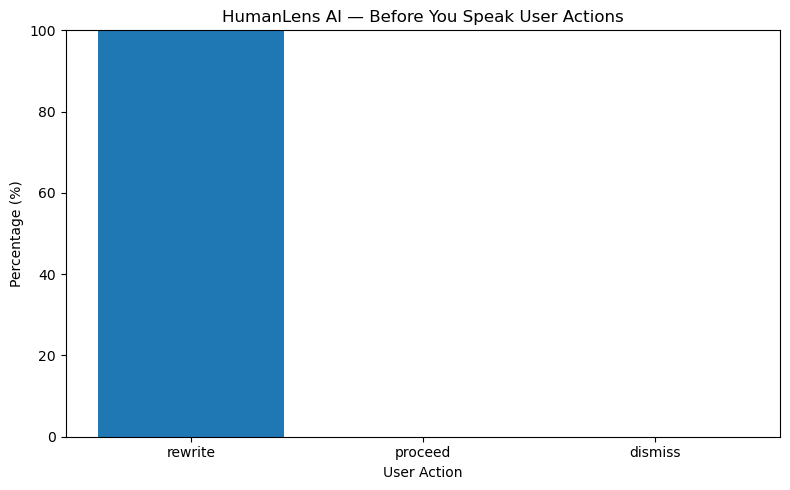

Chart saved to: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\intervention_user_actions.png

User-action analysis completed.


In [8]:
# ============================================================
# STEP 10 — USER ACTION & INTERVENTION OUTCOME ANALYSIS
# ============================================================

# Count user actions only for triggered interventions
action_counts = triggered_data["user_action"].value_counts()

# Ensure all expected actions exist
for action in ["rewrite", "proceed", "dismiss"]:
    if action not in action_counts:
        action_counts[action] = 0

action_counts = action_counts[
    ["rewrite", "proceed", "dismiss"]
]

# ------------------------------------------------------------
# Outcome summary
# ------------------------------------------------------------

action_summary = pd.DataFrame({
    "user_action": action_counts.index,
    "count": action_counts.values
})

action_summary["percentage"] = (
    action_summary["count"] / triggered_count * 100
)

display(action_summary)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    action_summary["user_action"],
    action_summary["percentage"]
)

plt.xlabel("User Action")
plt.ylabel("Percentage (%)")
plt.title("HumanLens AI — Before You Speak User Actions")

plt.ylim(0, 100)
plt.tight_layout()

action_plot_path = (
    RESULTS_DIR / "intervention_user_actions.png"
)

plt.savefig(
    action_plot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {action_plot_path}")
print("\nUser-action analysis completed.")

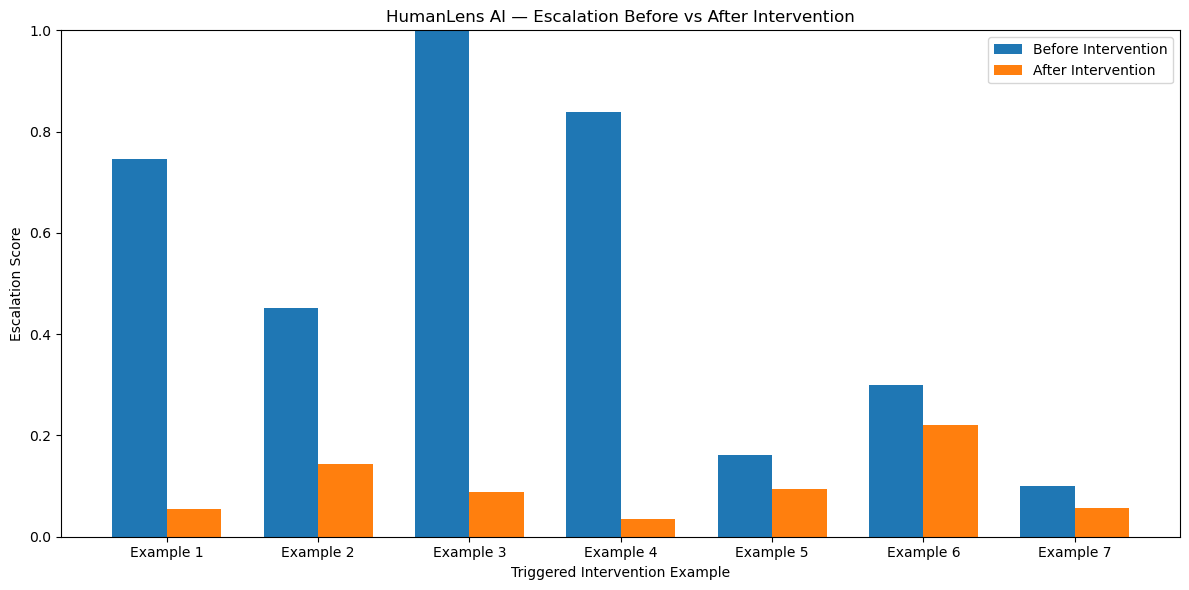

Visualization saved to: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\intervention_escalation_comparison.png


In [9]:
# ============================================================
# STEP 11 — BEFORE vs AFTER ESCALATION
# ============================================================

plot_data = triggered_data.reset_index(drop=True)

x = np.arange(len(plot_data))
width = 0.36

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    plot_data["original_escalation_score"],
    width,
    label="Before Intervention"
)

plt.bar(
    x + width / 2,
    plot_data["revised_escalation_score"],
    width,
    label="After Intervention"
)

plt.xlabel("Triggered Intervention Example")
plt.ylabel("Escalation Score")
plt.title("HumanLens AI — Escalation Before vs After Intervention")

plt.xticks(
    x,
    [f"Example {i + 1}" for i in x]
)

plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

escalation_plot_path = (
    RESULTS_DIR / "intervention_escalation_comparison.png"
)

plt.savefig(
    escalation_plot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Visualization saved to: {escalation_plot_path}")

In [10]:
# ============================================================
# STEP 12 — INTERVENTION EFFECTIVENESS SUMMARY
# ============================================================

effectiveness_summary = {
    "total_examples": int(total_examples),
    "triggered_interventions": int(triggered_count),

    "rewrite_count": int(rewrite_count),
    "proceed_count": int(proceed_count),
    "dismiss_count": int(dismiss_count),

    "rewrite_rate": float(rewrite_rate),
    "acceptance_rate": float(acceptance_rate),

    "mean_original_toxicity": float(mean_original_toxicity),
    "mean_revised_toxicity": float(mean_revised_toxicity),
    "mean_toxicity_reduction": float(mean_toxicity_reduction),
    "toxicity_reduction_rate": float(toxicity_reduction_rate),

    "mean_original_escalation": float(mean_original_escalation),
    "mean_revised_escalation": float(mean_revised_escalation),
    "mean_escalation_reduction": float(mean_escalation_reduction),
    "escalation_reduction_rate": float(escalation_reduction_rate),

    "mean_intervention_latency_ms": float(mean_latency_ms),
    "median_intervention_latency_ms": float(median_latency_ms),

    "evaluation_status": "controlled demonstration",
    "real_user_study": False
}

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

summary_df = pd.DataFrame(
    list(effectiveness_summary.items()),
    columns=["metric", "value"]
)

display(summary_df)

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

summary_csv_path = (
    RESULTS_DIR / "intervention_effectiveness_summary.csv"
)

summary_df.to_csv(
    summary_csv_path,
    index=False
)

# ------------------------------------------------------------
# Save JSON
# ------------------------------------------------------------

import json

summary_json_path = (
    RESULTS_DIR / "intervention_effectiveness_summary.json"
)

with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(
        effectiveness_summary,
        f,
        indent=2
    )

print(f"\nCSV saved: {summary_csv_path}")
print(f"JSON saved: {summary_json_path}")
print("\nIntervention effectiveness summary completed.")

,metric,value
0,total_examples,10
1,triggered_interventions,7
2,rewrite_count,7
3,proceed_count,0
4,dismiss_count,0
5,rewrite_rate,1.0
6,acceptance_rate,1.0
7,mean_original_toxicity,0.514114
8,mean_revised_toxicity,0.099343
9,mean_toxicity_reduction,0.414771



CSV saved: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\intervention_effectiveness_summary.csv
JSON saved: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\intervention_effectiveness_summary.json

Intervention effectiveness summary completed.


## Intervention Outcome Interpretation

The intervention is evaluated using changes between the original and
post-intervention messages.

### Positive Intervention Outcome

An intervention is considered beneficial in this controlled evaluation
when:

- toxicity decreases,
- escalation score decreases,
- the user chooses to rewrite the message, and
- the intervention operates within an acceptable latency.

### Neutral Outcome

A neutral outcome occurs when the user proceeds without modifying the
message or when the measured score remains approximately unchanged.

This does not automatically indicate intervention failure because the
system is designed to preserve user agency.

### Negative Outcome

A negative outcome occurs when:

- toxicity increases after revision,
- escalation increases after revision, or
- the intervention is triggered unnecessarily on low-risk content.

### Interpretation Rule

The results must be interpreted together with the intervention trigger,
user action, toxicity change, escalation change, and latency.

A reduction in model score alone does not prove that a user's real-world
behavior improved.

### Research Limitation

The current evaluation uses controlled demonstration examples rather
than observations from a real user study.

Therefore, the results demonstrate that the HumanLens intervention
evaluation pipeline can measure potential outcomes, but they do not
establish causal behavioral effectiveness.

A future controlled user study should compare intervention and
non-intervention conditions using independently annotated communication
outcomes.

In [11]:
# ============================================================
# STEP 14 — INTERVENTION EVALUATION VALIDATION
# ============================================================

# ------------------------------------------------------------
# Dataset validation
# ------------------------------------------------------------

assert len(intervention_data) == 10
assert triggered_count == int(
    intervention_data["intervention_triggered"].sum()
)

# ------------------------------------------------------------
# Required columns
# ------------------------------------------------------------

required_columns = [
    "original_text",
    "revised_text",
    "original_toxicity",
    "revised_toxicity",
    "toxicity_change",
    "original_escalation_score",
    "revised_escalation_score",
    "escalation_change",
    "intervention_triggered",
    "user_action",
    "intervention_latency_ms"
]

missing_columns = [
    col for col in required_columns
    if col not in intervention_data.columns
]

assert not missing_columns, f"Missing columns: {missing_columns}"

# ------------------------------------------------------------
# Score validation
# ------------------------------------------------------------

assert intervention_data[
    ["original_toxicity", "revised_toxicity"]
].apply(lambda x: x.between(0, 1)).all().all()

assert intervention_data[
    ["original_escalation_score", "revised_escalation_score"]
].apply(lambda x: x.between(0, 1)).all().all()

# ------------------------------------------------------------
# Change calculations
# ------------------------------------------------------------

assert np.allclose(
    intervention_data["toxicity_change"],
    intervention_data["original_toxicity"]
    - intervention_data["revised_toxicity"]
)

assert np.allclose(
    intervention_data["escalation_change"],
    intervention_data["original_escalation_score"]
    - intervention_data["revised_escalation_score"]
)

# ------------------------------------------------------------
# User-action validation
# ------------------------------------------------------------

valid_actions = {"rewrite", "proceed", "dismiss"}

assert set(
    intervention_data["user_action"]
).issubset(valid_actions)

# ------------------------------------------------------------
# Output-file validation
# ------------------------------------------------------------

required_output_files = [
    "intervention_toxicity_comparison.png",
    "intervention_escalation_comparison.png",
    "intervention_user_actions.png",
    "intervention_effectiveness_summary.csv",
    "intervention_effectiveness_summary.json"
]

missing_files = [
    filename
    for filename in required_output_files
    if not (RESULTS_DIR / filename).exists()
]

assert not missing_files, f"Missing output files: {missing_files}"

print("=" * 60)
print("🎉 NOTEBOOK 14 — VALIDATION PASSED")
print("=" * 60)

print(f"Examples evaluated: {len(intervention_data)}")
print(f"Triggered interventions: {triggered_count}")
print(f"Rewrites: {rewrite_count}")
print(f"Mean toxicity reduction: {mean_toxicity_reduction:.4f}")
print(f"Mean escalation reduction: {mean_escalation_reduction:.4f}")
print(f"Mean latency: {mean_latency_ms:.2f} ms")

print("\nEvaluation status: CONTROLLED DEMONSTRATION")
print("Real user study: NO")
print("\nAll required outputs are present.")

🎉 NOTEBOOK 14 — VALIDATION PASSED
Examples evaluated: 10
Triggered interventions: 7
Rewrites: 7
Mean toxicity reduction: 0.4148
Mean escalation reduction: 0.4148
Mean latency: 51.14 ms

Evaluation status: CONTROLLED DEMONSTRATION
Real user study: NO

All required outputs are present.


In [1]:
# ============================================================
# STEP 15 — REAL HUMANLENS PIPELINE INTEGRATION TEST
# ============================================================

import sys
from pathlib import Path

# ------------------------------------------------------------
# Add HumanLens project root to Python path
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Project root exists:", PROJECT_ROOT.exists())
print("src exists:", (PROJECT_ROOT / "src").exists())

# ------------------------------------------------------------
# Import complete HumanLens pipeline
# ------------------------------------------------------------

from src.pipeline import HumanLensPipeline

print("✅ HumanLensPipeline imported successfully.")

Project root: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml
Project root exists: True
src exists: True
✅ HumanLensPipeline imported successfully.


In [2]:
# ============================================================
# STEP 16 — INITIALIZE COMPLETE HUMANLENS PIPELINE
# ============================================================

print("Initializing HumanLens AI pipeline...")
print("This may take a little time because ML components are loaded.")

humanlens = HumanLensPipeline()

print("\n" + "=" * 60)
print("✅ HUMANLENS PIPELINE INITIALIZED SUCCESSFULLY")
print("=" * 60)

Initializing HumanLens AI pipeline...
This may take a little time because ML components are loaded.


C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.7.2. This might lead to b


✅ HUMANLENS PIPELINE INITIALIZED SUCCESSFULLY


C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.7.2. This might lead to b

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.pipeline import HumanLensPipeline

print("Initializing HumanLens AI pipeline...")
humanlens = HumanLensPipeline()

print("\n" + "=" * 60)
print("✅ HUMANLENS PIPELINE READY")
print("=" * 60)

Initializing HumanLens AI pipeline...


C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.7.2. This might lead to b


✅ HUMANLENS PIPELINE READY


C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\shash\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.7.2. This might lead to b

In [3]:
# Fix compatibility issue between saved sklearn 1.8.0 model
# and current sklearn 1.7.2 runtime

if hasattr(humanlens.toxicity_scorer, "fast_model"):
    if humanlens.toxicity_scorer.fast_model is not None:
        if not hasattr(humanlens.toxicity_scorer.fast_model, "multi_class"):
            humanlens.toxicity_scorer.fast_model.multi_class = "auto"

print("✅ Toxicity model compatibility fix applied.")

✅ Toxicity model compatibility fix applied.


In [4]:
test_text = (
    "I am really frustrated with this situation. "
    "You are not listening to what I am saying."
)

print("Running HumanLens AI analysis...")
result = humanlens.analyze(text=test_text)

print("\n" + "=" * 60)
print("✅ HUMANLENS ANALYSIS COMPLETED")
print("=" * 60)

print("Status:", result.get("status"))
print("Language:", result.get("language"))
print("Routing:", result.get("routing_path"))

print("\n--- TEXT ANALYSIS ---")
print("Toxicity:", result.get("text", {}).get("toxicity"))
print("Aggression:", result.get("text", {}).get("aggression"))
print("Emotion:", result.get("text", {}).get("emotion"))
print("Confidence:", result.get("text", {}).get("confidence"))

print("\n--- MULTIMODAL FUSION ---")
print("Fusion Score:", result.get("fusion", {}).get("score"))
print("Risk Level:", result.get("fusion", {}).get("risk_level"))
print("Fusion Confidence:", result.get("fusion", {}).get("confidence"))

print("\n--- INTERVENTION ---")
print("Triggered:", result.get("intervention_triggered"))

print("\n--- MODALITIES ---")
print("Text:", "text" in result)
print("Voice:", result.get("voice", {}).get("status"))
print("Face:", result.get("face", {}).get("status"))
print("Behavior:", result.get("behavior", {}).get("status"))

Running HumanLens AI analysis...

✅ HUMANLENS ANALYSIS COMPLETED
Status: success
Language: English
Routing: text_ml

--- TEXT ANALYSIS ---
Toxicity: 0.0926
Aggression: 0.0185
Emotion: curiosity
Confidence: 0.8147

--- MULTIMODAL FUSION ---
Fusion Score: 0.2151
Risk Level: Low Risk
Fusion Confidence: 0.8147

--- INTERVENTION ---
Triggered: False

--- MODALITIES ---
Text: True
Voice: unavailable
Face: unavailable
Behavior: unavailable


In [ ]:
abusive_text = (
    "Fuck you, you stupid bitch. "
    "You are a useless bastard and I am extremely angry with you."
)

print("Running abusive-text test...")
abusive_result = humanlens.analyze(text=abusive_text)

print("\n" + "=" * 60)
print("🔥 ABUSIVE TEXT TEST")
print("=" * 60)

print("Status:", abusive_result.get("status"))
print("Language:", abusive_result.get("language"))

print("\n--- TEXT ANALYSIS ---")
print("Toxicity:", abusive_result.get("text", {}).get("toxicity"))
print("Aggression:", abusive_result.get("text", {}).get("aggression"))
print("Emotion:", abusive_result.get("text", {}).get("emotion"))
print("Confidence:", abusive_result.get("text", {}).get("confidence"))

print("\n--- FUSION ---")
print("Fusion Score:", abusive_result.get("fusion", {}).get("score"))
print("Risk Level:", abusive_result.get("fusion", {}).get("risk_level"))
print("Fusion Confidence:", abusive_result.get("fusion", {}).get("confidence"))

print("\n--- ROUTING ---")
print("Routing Path:", abusive_result.get("routing_path"))

print("\n--- INTERVENTION ---")
print("Triggered:", abusive_result.get("intervention_triggered"))
print("Card:", abusive_result.get("intervention_card"))

Running abusive-text test...
